# LMUL gem5 Workflow

This notebook walks you through the full LMUL vs IEEE gem5 workflow:

1. (Optional) Environment checks and one-time setup.
2. Build the BF16 matrix-multiply benchmark.
3. Run `compare_lmul_vs_ieee.sh` for a list of matrix sizes.
4. Concatenate the generated `performance_comparison_*.txt` files into one summary.

> **Usage assumption:** Start Jupyter with the current working directory set to `gem5-sim/`.
> All paths below are relative to this folder.


In [ ]:
from pathlib import Path
import subprocess
from utils.utils import *
import re
import pandas as pd

GEM5_SIM = Path.cwd()
REPO_ROOT = GEM5_SIM.parent

print(f"GEM5_SIM = {GEM5_SIM}")
print(f"REPO_ROOT = {REPO_ROOT}")


GEM5_SIM = /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration/gem5-sim
REPO_ROOT = /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration


## 0. Clone Gem5 Repo

In [2]:
# gem5_dir = REPO_ROOT / "gem5"

# if gem5_dir.is_dir():
#     print(f"gem5 directory already exists at: {gem5_dir}")
# else:
#     print(f"Cloning gem5 into: {gem5_dir.parent}")
#     clone_cmd = [
#         "git",
#         "clone",
#         "https://github.com/gem5/gem5.git",
#         str(gem5_dir),
#     ]
#     clone_result = subprocess.run(clone_cmd, cwd=REPO_ROOT)
#     if clone_result.returncode != 0:
#         raise RuntimeError(f"Failed to clone gem5 (exit code {clone_result.returncode})")
#     else:
#         print("Successfully cloned gem5.")

# if gem5_dir.is_dir():
#     # Checkout stable branch
#     checkout_result = subprocess.run(["git", "checkout", "stable"], cwd=gem5_dir)
#     if checkout_result.returncode != 0:
#         print("Warning: 'git checkout stable' failed; leaving gem5 on its current branch.")
#     else:
#         print("Checked out 'stable' branch in gem5.")

#     # Install Python requirements
#     req_path = gem5_dir / "requirements.txt"
#     if req_path.is_file():
#         pip_result = subprocess.run(["pip", "install", "-r", str(req_path)], cwd=gem5_dir)
#         if pip_result.returncode != 0:
#             print("Warning: 'pip install -r requirements.txt' failed; see output above.")
#         else:
#             print("Installed gem5 Python requirements.")
#     else:
#         print(f"No requirements.txt found at {req_path}; skipping pip install.")


## 1. Check system compatability

In [3]:
# # Uncomment to run

# scripts = [
#     REPO_ROOT / "gem5-sim" / "scripts" / "check_compatibility.sh",
#     REPO_ROOT / "gem5-sim" / "scripts" / "check_gem5_dependencies.sh",
# ]

# for script in scripts:
#     subprocess.run([str(script)], cwd=REPO_ROOT, check=True)

## 2. One-time setup

This cell builds the gem5 model and validates it afterwards. It may require significant time and memory.


In [4]:
# # Uncomment to run

# scripts = [
#     REPO_ROOT / "gem5-sim" / "scripts" / "install_model.sh",
#     REPO_ROOT / "gem5-sim" / "scripts" / "test_accelerator.sh",
# ]

# for script in scripts:
#     subprocess.run([str(script)], cwd=REPO_ROOT, check=True)

## 3. Build the BF16 matrix-multiply benchmark

This uses the existing Makefile in `benchmarks/matrix_multiply/` to build `matrix_multiply_no_printf.arm`.


In [5]:
# # Uncomment to run
# mm_dir = GEM5_SIM / "benchmarks" / "matrix_multiply"
# print(f"Building in: {mm_dir}")

# subprocess.run(["make", "matrix_multiply_no_printf.arm"], cwd=mm_dir, check=True)


## 4. Run LMUL vs IEEE comparisons for multiple sizes

Configure the sizes, PE array, and CPU model here. The cells below will call
`gem5-sim/scripts/compare_lmul_vs_ieee.sh` once per size.


In [6]:
# Experiment configuration
SIZES = [4, 64, 256, 512] # for full tests
# SIZES = [4, 64]
PE_ROWS = 8
PE_COLS = 8
CPU_MODEL = "o3"           # "timing" (slower simulation, faster runtime) or "o3" (faster simulation, slower runtime)
INCLUDE_CPU_LMUL = True # Set to False to skip CPU LMUL runs
EXTRACT_OUTPUTS = True # Set to True to validate output results

compare_script = REPO_ROOT / "gem5-sim" / "scripts" / "compare_lmul_vs_ieee.sh"


In [7]:
# Uncomment to run the comparison scripts
# for n in SIZES:
#     cmd = [
#         str(compare_script),
#         "--size", str(n),
#         "--pe-rows", str(PE_ROWS),
#         "--pe-cols", str(PE_COLS),
#         "--cpu-model", CPU_MODEL,
#     ]
#     if n < 512 and INCLUDE_CPU_LMUL:
#         cmd.append("--include-cpu-lmul")
#     if not EXTRACT_OUTPUTS:
#         cmd.append("--no-output-extraction")

#     print("\nRunning:", " ".join(cmd))
#     result = subprocess.run(cmd, cwd=REPO_ROOT)
#     if result.returncode != 0:
#         print(f"Command failed for size {n} (exit {result.returncode})")
#         break


## 5. Check Output Validation



In [ ]:
# # Uncomment to run

# if EXTRACT_OUTPUTS:
#     validate_all_runs(GEM5_SIM, SIZES)
# else:
#     print("Output validation skipped (EXTRACT_OUTPUTS is False).")


=== Validation for size 4 ===
[LMUL Accel vs LMUL reference]
Missing LMUL artifacts for size 4; skipping (result_4.bin, inputs_4.bin).
[IEEE CPU vs IEEE reference]
Missing IEEE artifacts for size 4; skipping (result_4.bin, inputs_4.bin).

=== Validation for size 64 ===
[LMUL Accel vs LMUL reference]
Missing LMUL artifacts for size 64; skipping (result_64.bin, inputs_64.bin).
[IEEE CPU vs IEEE reference]
Missing IEEE artifacts for size 64; skipping (result_64.bin, inputs_64.bin).

=== Validation for size 256 ===
[LMUL Accel vs LMUL reference]
Missing LMUL artifacts for size 256; skipping (result_256.bin, inputs_256.bin).
[IEEE CPU vs IEEE reference]
Missing IEEE artifacts for size 256; skipping (result_256.bin, inputs_256.bin).

=== Validation for size 512 ===
[LMUL Accel vs LMUL reference]
Missing LMUL artifacts for size 512; skipping (result_512.bin, inputs_512.bin).
[IEEE CPU vs IEEE reference]
Missing IEEE artifacts for size 512; skipping (result_512.bin, inputs_512.bin).


## 6. Parse performance_comparison_*.txt into a summary table

This cell parses all available `performance_comparison_<size>.txt` files,
extracts **Simulation Time (s)**, **CPU Cycles**, and **Estimated total energy (µJ)**
for each path (LMUL Accel, IEEE, and CPU LMUL when present), and builds a
`pandas` DataFrame similar to the **Core Results Breakdown** table in `results.ipynb`.

It also writes the raw concatenated text to `performance_comparison_all.txt` for convenience.


In [9]:
out_dir = GEM5_SIM / "lmul_vs_ieee_comparison"
concat_path = out_dir / "performance_comparison_all.txt"

all_rows = []

for n in SIZES:
    path = out_dir / f"performance_comparison_{n}.txt"
    if not path.is_file():
        print(f"Missing: {path}")
        continue

    all_rows.extend(parse_performance_comparison_txt(path, size=n))

if all_rows:
    core = pd.DataFrame(all_rows)

    # Normalize path names so utils.plot_table() receives expected labels.
    core["Path"] = core["Path"].replace({
        "LMUL Accel": "LMUL ACL",
        "IEEE CPU": "IEEE",
    })

    core = core.sort_values(["Size", "Path"]).reset_index(drop=True)
    display(core)
else:
    print("No performance comparison rows parsed.")

,Size,Path,Sim Time (s),CPU Cycles,Energy (µJ),Instructions
0,4,CPU LMUL,0.000090,287118,2.991830e+02,11179
1,4,IEEE,0.000089,283465,2.958560e+02,10277
2,4,LMUL ACL,0.000074,235119,2.445920e+02,8340
3,64,CPU LMUL,0.026559,84854002,8.579437e+04,8657518
4,64,IEEE,0.007192,22976555,2.333564e+04,876968
5,64,LMUL ACL,0.000812,2593525,2.451232e+03,143927
6,256,CPU LMUL,1.703653,5442981233,5.534355e+06,546338021
7,256,IEEE,0.446429,1426290298,1.473231e+06,47467549
8,256,LMUL ACL,0.011950,38180364,3.568309e+04,2248606
9,512,IEEE,3.512644,11222503683,1.161314e+07,369392896


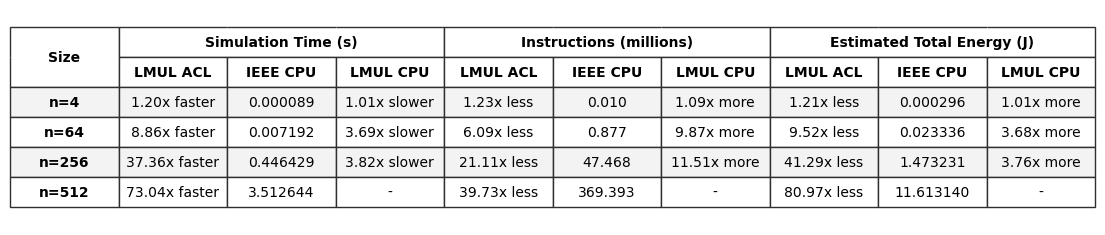

In [10]:
plot_table(SIZES, core)